# 04 — Evaluation & Hybrid Comparison

Brings everything together on the held-out **test set**:

* **Before vs. after tuning** comparison for both the MLP and the
  Autoencoder (tables + plots from the persisted histories).
* Pure MLP performance — per-class metrics, confusion matrix, ROC curves.
* Pure Autoencoder performance — binary attack/benign, ROC curve.
* **Hybrid** = AE flags anomaly, MLP classifies — same logic the production
  `SmartTIDS_Predictor` runs.
* SHAP explanations on a sample.
* Inference latency.
* Final discussion and conclusions.

---

## Table of Contents

1. [Load test set and artifacts](#1.-Load-test-set-and-artifacts)
2. [Before vs after tuning — MLP & AE](#2.-Before-vs-after-tuning)
3. [Pure MLP metrics + confusion matrix](#3.-Pure-MLP-metrics)
4. [MLP — ROC and Precision-Recall curves](#4.-MLP-ROC-and-PR-curves)
5. [Pure Autoencoder metrics (binary)](#5.-Pure-Autoencoder-metrics)
6. [Autoencoder ROC curve](#6.-Autoencoder-ROC-curve)
7. [Hybrid pipeline (AE gates, MLP classifies)](#7.-Hybrid-pipeline)
8. [Strong visual comparison — MLP vs AE vs Hybrid](#8.-Strong-visual-comparison)
9. [Learning curves (training histories)](#9.-Learning-curves)
10. [SHAP explanations](#10.-SHAP-explanations)
11. [Inference latency](#11.-Inference-latency)
12. [Healthcheck](#12.-Healthcheck)
13. [Final discussion & conclusions](#13.-Final-discussion-&-conclusions)

---


In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from src import config as cfg
from src.inference import SmartTIDS_Predictor
sns.set_theme(style="whitegrid")


## 1. Load test set and artifacts

In [2]:
import csv
import gc

# --- Metadata (small, cheap) -------------------------------------------
scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)
with open(cfg.LABEL_MAP_FILE)    as f: label_map = {int(k): v for k, v in json.load(f).items()}
inv_map = {v: k for k, v in label_map.items()}
class_names = [label_map[i] for i in range(len(label_map))]

# --- Stream the test CSV row-by-row via the stdlib `csv` module --------
# Pandas' C parser keeps OOM-ing / access-violating on this 190 MB file
# (it pre-allocates large native buffers per column). Stdlib csv reads
# one row at a time, so peak memory stays bounded.
BUF = 100_000   # rows held in the staging buffer before we flush a slab
X_chunks = []
y_chunks = []

with open(cfg.PROCESSED_DIR / "test.csv", "r", encoding="utf-8", newline="") as fh:
    reader = csv.reader(fh)
    header = next(reader)
    feat_idx = [header.index(c) for c in feature_names]
    lbl_idx  = header.index(cfg.LABEL_COL)

    X_buf = np.empty((BUF, len(feature_names)), dtype=np.float32)
    y_buf = np.empty(BUF, dtype=np.int32)
    pos = 0
    n_total = 0
    n_kept  = 0

    for row in reader:
        n_total += 1
        lbl = row[lbl_idx]
        if lbl not in inv_map:
            continue
        # Fill one row of the float32 buffer.
        for j, k in enumerate(feat_idx):
            v = row[k]
            X_buf[pos, j] = float(v) if v else 0.0
        y_buf[pos] = inv_map[lbl]
        pos += 1
        n_kept += 1
        if pos == BUF:
            # Scale this slab and stash; reset the buffer (no fresh alloc).
            X_chunks.append(scaler.transform(X_buf).astype(np.float32))
            y_chunks.append(y_buf.copy())
            pos = 0

    # Flush any remainder.
    if pos > 0:
        X_chunks.append(scaler.transform(X_buf[:pos]).astype(np.float32))
        y_chunks.append(y_buf[:pos].copy())

y_true = np.concatenate(y_chunks)
X      = np.concatenate(X_chunks, axis=0)
del X_chunks, y_chunks, X_buf, y_buf
gc.collect()

# --- Load the trained models last --------------------------------------
mlp = tf.keras.models.load_model(cfg.MLP_MODEL_FILE, compile=False)
ae  = tf.keras.models.load_model(cfg.AE_MODEL_FILE,  compile=False)
ae_threshold = json.loads(cfg.AE_THRESHOLD_FILE.read_text())["threshold"]

print(f"Test rows read     : {n_total:,}")
print(f"Test rows kept     : {n_kept:,}  (dropped {n_total - n_kept:,} with rare labels)")
print(f"X shape            : {X.shape}  dtype={X.dtype}")
print(f"y_true shape       : {y_true.shape}  dtype={y_true.dtype}")
print(f"Classes            : {len(label_map)}")
print(f"AE threshold       : {ae_threshold:.6f}")


2026-05-18 09:57:30,026 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Test rows read     : 424,172
Test rows kept     : 424,172  (dropped 0 with rare labels)
X shape            : (424172, 77)  dtype=float32
y_true shape       : (424172,)  dtype=int32
Classes            : 12
AE threshold       : 0.002193


## 2. Before vs after tuning — MLP & AE

Load the persisted training histories from NB 02 / NB 03 and compare the
**baseline vs tuned** models. We compare:

* MLP — validation macro-F1, validation accuracy, training loss curves.
* AE — validation MSE / MAE curves.


MLP — baseline vs tuned (validation):
           metric  baseline  tuned  delta
best val macro-F1    0.7376 0.7506 0.0130
best val accuracy    0.9800 0.9841 0.0041


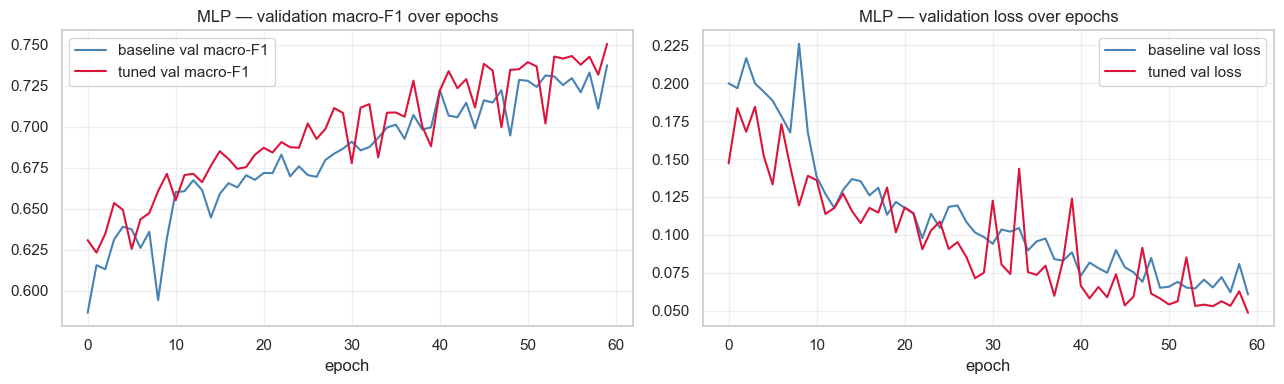


MLP tuning trials (top-5 by mean macro-F1):
   hidden_units  dropout  learning_rate  batch_size  mean_macro_f1  std_macro_f1                                                  fold_scores
     [512, 256]      0.2         0.0010        1024       0.596930      0.026306 [0.5833066403968108, 0.6337221904909435, 0.5737611541889387]
     [256, 128]      0.2         0.0010        1024       0.586388      0.006483 [0.5882477739083168, 0.5932339825146463, 0.5776829712085122]
[512, 256, 128]      0.4         0.0005        1024       0.531131      0.013230 [0.5223423325944834, 0.5498296767776797, 0.5212206277498713]
     [512, 256]      0.3         0.0002        1024       0.523609      0.013871 [0.5225300263191606, 0.5411109047842744, 0.5071858339238355]
 [256, 128, 64]      0.3         0.0005        1024       0.518941      0.005212 [0.5119516350957349, 0.5204070782985355, 0.5244628784722812]

AE tuning trials (top-5 by val MSE):
     encoder_units  latent_dim  learning_rate  val_mse  val_mae  

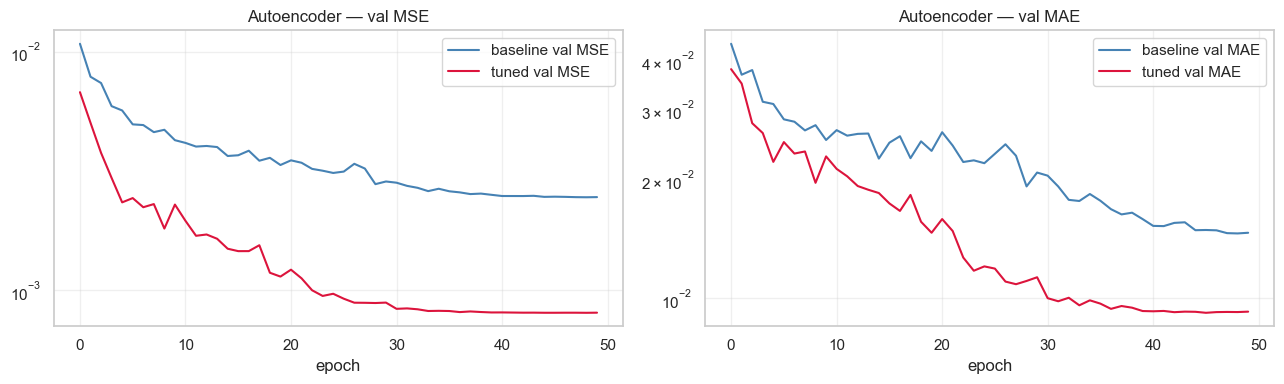


Autoencoder — baseline vs tuned (validation):
      metric  baseline   tuned    delta
best val MSE   0.00246 0.00081 -0.00165
best val MAE   0.01459 0.00919 -0.00541


In [3]:
# --- Load saved histories (gracefully degrade if absent) ----------------
def _load_json(p):
    try:
        with open(p) as f: return json.load(f)
    except FileNotFoundError:
        print(f"  (missing) {p}")
        return None

mlp_baseline = _load_json(cfg.MODELS_DIR / "mlp_baseline_history.json")
mlp_tuned    = _load_json(cfg.MODELS_DIR / "mlp_tuned_history.json")
ae_hist      = _load_json(cfg.MODELS_DIR / "ae_tuned_history.json")
mlp_tuning_df = pd.read_csv(cfg.MODELS_DIR / "mlp_tuning_results.csv") \
    if (cfg.MODELS_DIR / "mlp_tuning_results.csv").exists() else None
ae_tuning_df  = pd.read_csv(cfg.MODELS_DIR / "ae_tuning_results.csv") \
    if (cfg.MODELS_DIR / "ae_tuning_results.csv").exists() else None

# --- MLP before/after comparison ----------------------------------------
if mlp_baseline and mlp_tuned:
    base_vm = mlp_baseline["val_metrics"]
    tuned_f1 = max(mlp_tuned["f1_history"]) if mlp_tuned["f1_history"] else None
    # Recompute weighted f1 for tuned model on val from tuned model's accuracy history
    cmp_df = pd.DataFrame({
        "metric": ["best val macro-F1", "best val accuracy"],
        "baseline":   [base_vm["macro_f1"],
                       max(mlp_baseline["history"].get("val_accuracy", [np.nan]))],
        "tuned":      [tuned_f1,
                       max(mlp_tuned["history"].get("val_accuracy", [np.nan]))],
    })
    cmp_df["delta"] = cmp_df["tuned"] - cmp_df["baseline"]
    print("MLP — baseline vs tuned (validation):")
    print(cmp_df.round(4).to_string(index=False))

    # Side-by-side learning curves
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(mlp_baseline["f1_history"], label="baseline val macro-F1",
                 color="steelblue")
    axes[0].plot(mlp_tuned["f1_history"],    label="tuned val macro-F1",
                 color="crimson")
    axes[0].set_title("MLP — validation macro-F1 over epochs")
    axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(mlp_baseline["history"]["val_loss"], label="baseline val loss",
                 color="steelblue")
    axes[1].plot(mlp_tuned["history"]["val_loss"],    label="tuned val loss",
                 color="crimson")
    axes[1].set_title("MLP — validation loss over epochs")
    axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# --- Tuning trial heatmaps ----------------------------------------------
if mlp_tuning_df is not None:
    print("\nMLP tuning trials (top-5 by mean macro-F1):")
    print(mlp_tuning_df.head(5).to_string(index=False))

if ae_tuning_df is not None:
    print("\nAE tuning trials (top-5 by val MSE):")
    print(ae_tuning_df.head(5).to_string(index=False))

# --- AE before/after comparison -----------------------------------------
if ae_hist:
    base_h, tuned_h = ae_hist["baseline_history"], ae_hist["tuned_history"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(base_h["val_loss"],  label="baseline val MSE",  color="steelblue")
    axes[0].plot(tuned_h["val_loss"], label="tuned val MSE",     color="crimson")
    axes[0].set_yscale("log"); axes[0].set_title("Autoencoder — val MSE")
    axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(base_h["val_mae"],  label="baseline val MAE",   color="steelblue")
    axes[1].plot(tuned_h["val_mae"], label="tuned val MAE",      color="crimson")
    axes[1].set_yscale("log"); axes[1].set_title("Autoencoder — val MAE")
    axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    ae_cmp = pd.DataFrame({
        "metric": ["best val MSE", "best val MAE"],
        "baseline": [min(base_h["val_loss"]),  min(base_h["val_mae"])],
        "tuned":    [min(tuned_h["val_loss"]), min(tuned_h["val_mae"])],
    })
    ae_cmp["delta"] = ae_cmp["tuned"] - ae_cmp["baseline"]
    print("\nAutoencoder — baseline vs tuned (validation):")
    print(ae_cmp.round(5).to_string(index=False))


## 3. Pure MLP metrics + confusion matrix (test set)

Final MLP evaluation on the held-out test set. Accuracy alone is meaningless
on this imbalanced dataset, so we report **macro-F1**, per-class
precision/recall/F1, and a normalised confusion matrix.


                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9806    0.9901    340698
                     Bot     0.1988    0.9795    0.3305       293
                    DDoS     0.9946    0.9994    0.9970     19204
           DoS GoldenEye     0.9069    0.9974    0.9500      1544
                DoS Hulk     0.9259    0.9990    0.9611     34519
        DoS Slowhttptest     0.8457    0.9964    0.9149       825
           DoS slowloris     0.9652    0.9908    0.9779       869
             FTP-Patator     0.9412    0.9950    0.9673      1190
                PortScan     0.9914    0.9992    0.9953     23821
             SSH-Patator     0.4594    0.9921    0.6280       885
Web Attack - Brute Force     0.1621    0.9248    0.2759       226
        Web Attack - XSS     0.1463    0.0612    0.0863        98

                accuracy                         0.9839    424172
               macro avg     0.7115    0.9096    0.7562    424172
        

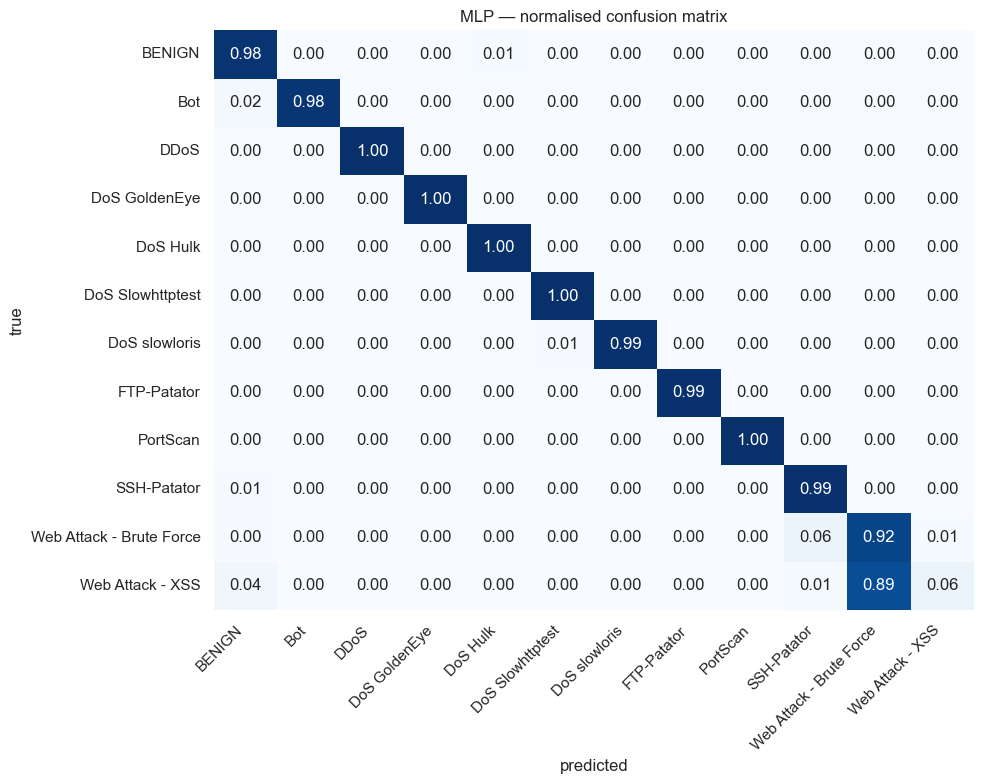

In [4]:
def plot_confusion(y_true, y_pred, class_names, normalize=True,
                   title="Confusion matrix", figsize=(10, 8)):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names,
                annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", cbar=False)
    plt.xlabel("predicted"); plt.ylabel("true"); plt.title(title)
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()


y_pred_mlp = mlp.predict(X, batch_size=4096, verbose=0).argmax(axis=1)
print(classification_report(y_true, y_pred_mlp, target_names=class_names,
                            digits=4, zero_division=0))
plot_confusion(y_true, y_pred_mlp, class_names, normalize=True,
               title="MLP — normalised confusion matrix")
plt.show()


## 4. MLP — ROC and Precision-Recall curves (one-vs-rest)

For each class we compute a ROC curve (TPR vs FPR) and a PR curve (Precision
vs Recall) treating it as "this class vs. everything else". This shows
which classes the MLP separates cleanly even before thresholding.


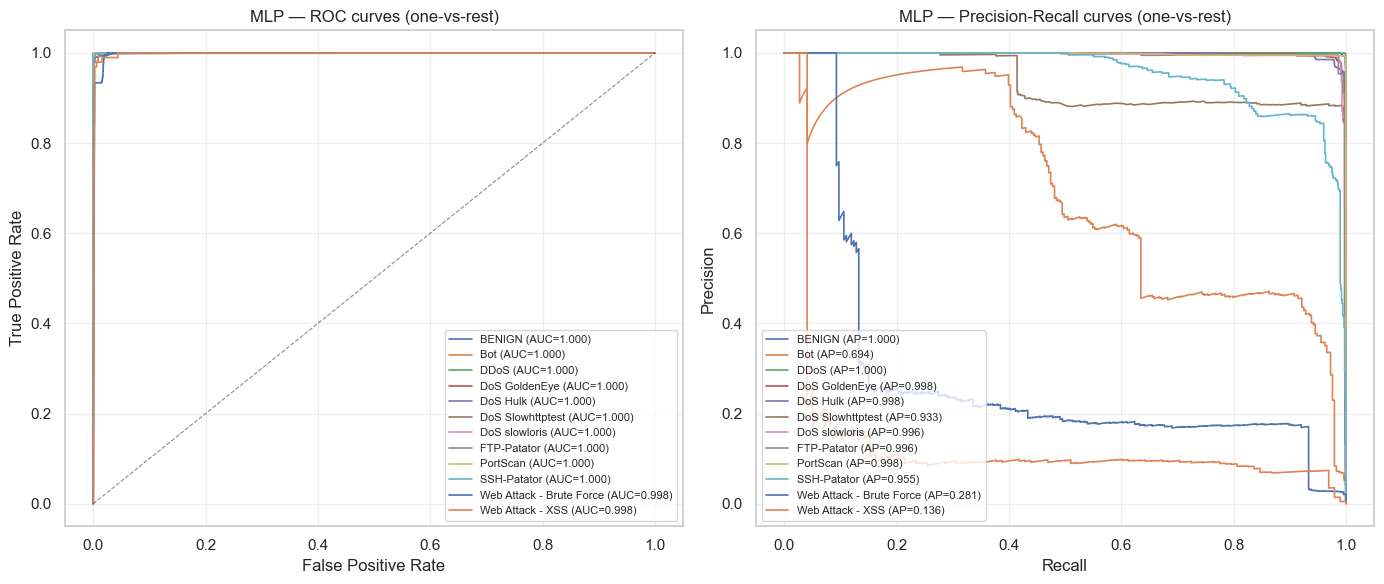

MLP macro-averaged ROC-AUC: 0.9995


In [5]:
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

mlp_proba_test = mlp.predict(X, batch_size=4096, verbose=0)
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC curves ----------------------------------------------------------
for i, cls in enumerate(class_names):
    if y_true_bin[:, i].sum() == 0:   # class absent from test split
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], mlp_proba_test[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=1.2, label=f"{cls} (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("MLP — ROC curves (one-vs-rest)")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

# --- PR curves -----------------------------------------------------------
for i, cls in enumerate(class_names):
    if y_true_bin[:, i].sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], mlp_proba_test[:, i])
    ap = average_precision_score(y_true_bin[:, i], mlp_proba_test[:, i])
    axes[1].plot(rec, prec, lw=1.2, label=f"{cls} (AP={ap:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("MLP — Precision-Recall curves (one-vs-rest)")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Aggregate macro-averaged AUC across classes for the summary table.
from sklearn.metrics import roc_auc_score
try:
    mlp_macro_auc = roc_auc_score(y_true, mlp_proba_test,
                                  multi_class="ovr", average="macro",
                                  labels=list(range(len(class_names))))
    print(f"MLP macro-averaged ROC-AUC: {mlp_macro_auc:.4f}")
except ValueError as e:
    mlp_macro_auc = float("nan")
    print(f"Could not compute macro-AUC: {e}")


## 5. Pure Autoencoder metrics (binary attack/benign)

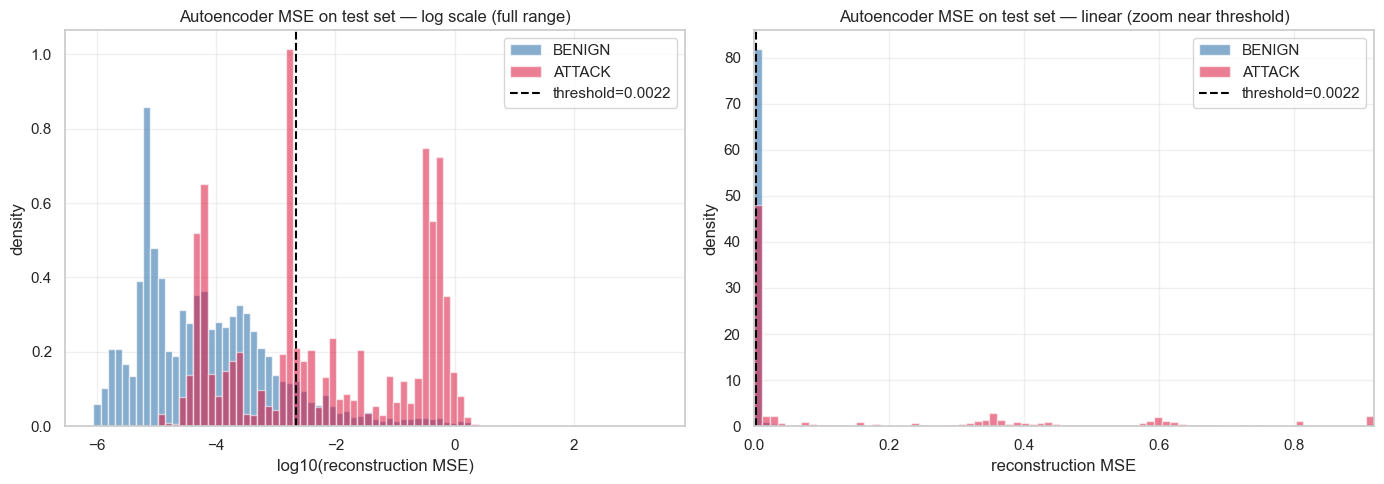

,tp,fp,fn,tn,precision,recall,f1,auc
0,45864,33986,37610,306712,0.574377,0.549441,0.561632,0.846907


In [6]:
def plot_reconstruction_error(err_benign, err_attack, threshold,
                              title="Autoencoder reconstruction error"):
    """Two-panel view of the reconstruction-error distribution.

    Errors span many orders of magnitude (threshold ~1e-3, max ~10^3),
    so a single linear plot collapses the useful region to one pixel.
    Left panel: log10 distribution (full range, both classes visible).
    Right panel: linear zoom near the threshold (decision boundary).
    """
    eps = 1e-12
    lb = np.log10(np.clip(err_benign, eps, None))
    la = np.log10(np.clip(err_attack, eps, None))
    lt = np.log10(max(threshold, eps))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bins_log = np.linspace(min(lb.min(), la.min()),
                           max(lb.max(), la.max()), 80)
    axes[0].hist(lb, bins=bins_log, density=True, alpha=0.65,
                 color="steelblue", label="BENIGN")
    axes[0].hist(la, bins=bins_log, density=True, alpha=0.55,
                 color="crimson",   label="ATTACK")
    axes[0].axvline(lt, color="black", ls="--",
                    label=f"threshold={threshold:.4f}")
    axes[0].set_xlabel("log10(reconstruction MSE)")
    axes[0].set_ylabel("density")
    axes[0].set_title(f"{title} — log scale (full range)")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    upper = max(threshold * 25, float(np.percentile(err_benign, 99.5)))
    bins_lin = np.linspace(0, upper, 80)
    axes[1].hist(np.clip(err_benign, None, upper), bins=bins_lin,
                 density=True, alpha=0.65, color="steelblue", label="BENIGN")
    axes[1].hist(np.clip(err_attack, None, upper), bins=bins_lin,
                 density=True, alpha=0.55, color="crimson",   label="ATTACK")
    axes[1].axvline(threshold, color="black", ls="--",
                    label=f"threshold={threshold:.4f}")
    axes[1].set_xlim(0, upper)
    axes[1].set_xlabel("reconstruction MSE")
    axes[1].set_ylabel("density")
    axes[1].set_title(f"{title} — linear (zoom near threshold)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()


def autoencoder_anomaly_metrics(err, y_is_attack, threshold):
    """Binary metrics for the AE used as 'is this an attack at all?'."""
    y_pred = (err > threshold).astype(int)
    tp = int(((y_pred == 1) & (y_is_attack == 1)).sum())
    fp = int(((y_pred == 1) & (y_is_attack == 0)).sum())
    fn = int(((y_pred == 0) & (y_is_attack == 1)).sum())
    tn = int(((y_pred == 0) & (y_is_attack == 0)).sum())
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-9)
    try:
        auc = roc_auc_score(y_is_attack, err)
    except ValueError:
        auc = float("nan")
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1, "auc": auc}


recon = ae.predict(X, batch_size=4096, verbose=0)
err = np.mean((X - recon) ** 2, axis=1)
y_is_attack = (y_true != inv_map["BENIGN"]).astype(int)

err_benign = err[y_is_attack == 0]
err_attack = err[y_is_attack == 1]
plot_reconstruction_error(err_benign, err_attack, ae_threshold,
                          title="Autoencoder MSE on test set")
plt.show()

ae_metrics = autoencoder_anomaly_metrics(err, y_is_attack, ae_threshold)
pd.DataFrame([ae_metrics])


## 6. Autoencoder ROC curve

Binary anomaly detection: reconstruction MSE as the score. The ROC-AUC
summarises how well the AE separates BENIGN from ATTACK across **all
thresholds** — useful because the operating threshold can be tuned per
deployment (precision vs recall trade-off).


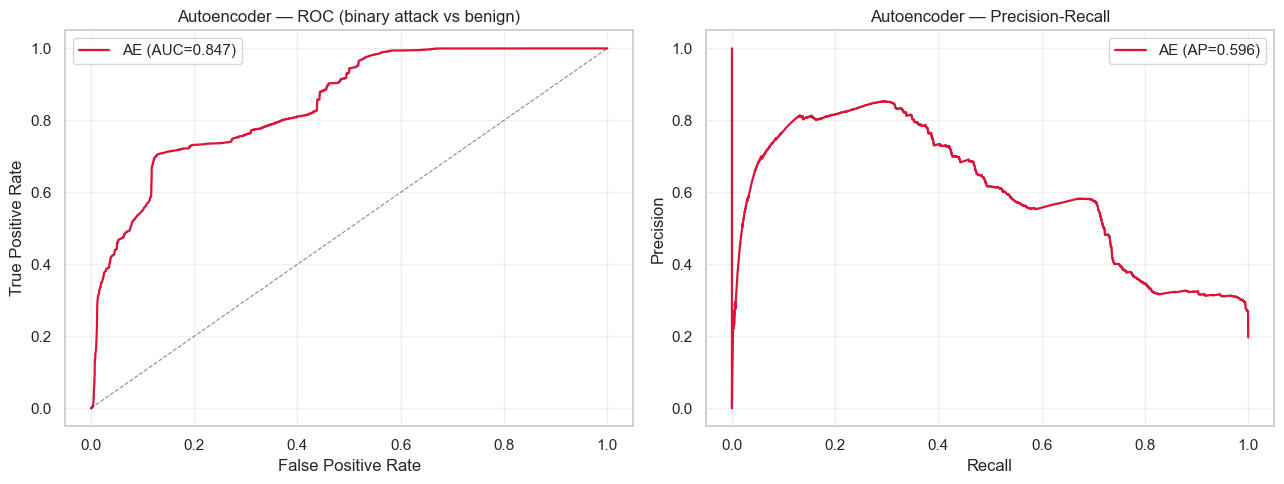

AE ROC-AUC: 0.8469   |   AE Average Precision: 0.5961


In [7]:
fpr_ae, tpr_ae, _ = roc_curve(y_is_attack, err)
ae_auc = auc(fpr_ae, tpr_ae)

prec_ae, rec_ae, _ = precision_recall_curve(y_is_attack, err)
ae_ap = average_precision_score(y_is_attack, err)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_ae, tpr_ae, lw=1.6, color="crimson", label=f"AE (AUC={ae_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Autoencoder — ROC (binary attack vs benign)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec_ae, prec_ae, lw=1.6, color="crimson",
             label=f"AE (AP={ae_ap:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Autoencoder — Precision-Recall")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"AE ROC-AUC: {ae_auc:.4f}   |   AE Average Precision: {ae_ap:.4f}")


## 7. Hybrid pipeline (AE gates / MLP classifies)

Decision rule (matches `SmartTIDS_Predictor`):

* `is_anomaly = err > threshold`
* if MLP says BENIGN but AE flags anomaly  -> mark `UNKNOWN_ANOMALY`
* otherwise                                -> MLP top class


In [8]:
mlp_proba = mlp.predict(X, batch_size=4096, verbose=0)
mlp_top   = mlp_proba.argmax(axis=1)
mlp_conf  = mlp_proba.max(axis=1)
anomaly   = err > ae_threshold

UNKNOWN_ID = -1
hybrid_pred = np.where(
    (mlp_top == inv_map["BENIGN"]) & anomaly,
    UNKNOWN_ID,
    mlp_top,
)

# Score against multi-class ground truth, ignoring UNKNOWN bucket.
mask = hybrid_pred != UNKNOWN_ID
print(f"UNKNOWN flagged: {(~mask).sum()} / {len(mask)} rows")
print(classification_report(
    y_true[mask], hybrid_pred[mask],
    target_names=class_names, digits=4, zero_division=0,
))


UNKNOWN flagged: 33429 / 424172 rows
                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9784    0.9890    307278
                     Bot     0.1988    0.9795    0.3305       293
                    DDoS     0.9946    0.9996    0.9971     19200
           DoS GoldenEye     0.9069    0.9974    0.9500      1544
                DoS Hulk     0.9259    0.9991    0.9611     34518
        DoS Slowhttptest     0.8457    0.9964    0.9149       825
           DoS slowloris     0.9652    0.9908    0.9779       869
             FTP-Patator     0.9412    0.9950    0.9673      1190
                PortScan     0.9914    0.9993    0.9953     23818
             SSH-Patator     0.4594    0.9921    0.6280       885
Web Attack - Brute Force     0.1621    0.9289    0.2761       225
        Web Attack - XSS     0.1463    0.0612    0.0863        98

                accuracy                         0.9825    390743
               macro avg     0.7115  

## 8. Strong visual comparison — MLP vs AE vs Hybrid

A single chart that summarises the three approaches on the test set:

* **MLP** — supervised, per-class macro-F1.
* **AE**  — unsupervised binary attack/benign, reported in binary terms.
* **Hybrid** — adds UNKNOWN_ANOMALY routing for novel attacks.

We also compute a binary attack/benign view of the MLP and the hybrid so all
three are directly comparable on the same axis.


Binary attack/benign comparison on test set:
          model  accuracy  precision  recall     f1
       MLP only    0.9843     0.9264  0.9995 0.9616
    Autoencoder    0.8312     0.5744  0.5494 0.5616
Hybrid (MLP|AE)    0.9055     0.6757  0.9996 0.8063


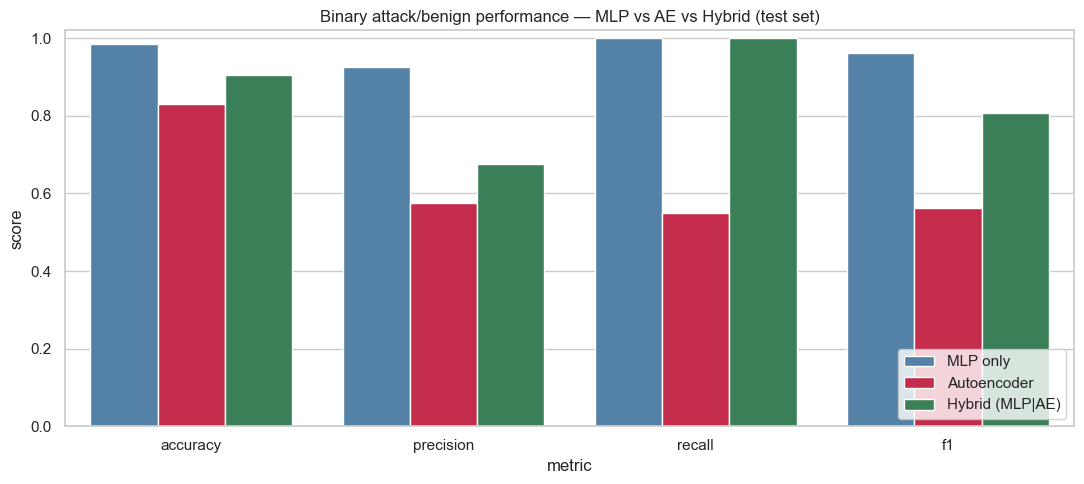

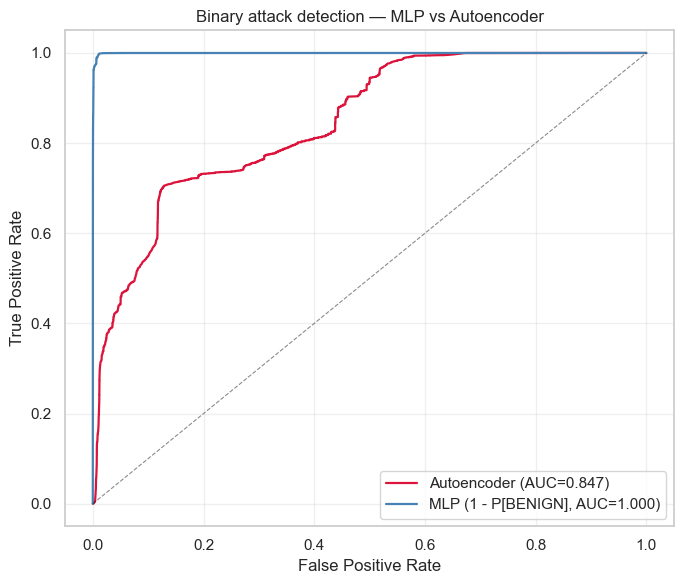

In [9]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

BENIGN_ID = inv_map["BENIGN"]

# --- binary views --------------------------------------------------------
y_attack_true = (y_true != BENIGN_ID).astype(int)
y_attack_mlp  = (y_pred_mlp != BENIGN_ID).astype(int)
y_attack_ae   = (err > ae_threshold).astype(int)
# Hybrid binary = attack if MLP says attack OR AE flags anomaly
y_attack_hyb  = ((y_pred_mlp != BENIGN_ID) | (err > ae_threshold)).astype(int)

def binary_row(name, y_pred):
    return {
        "model":     name,
        "accuracy":  accuracy_score(y_attack_true,  y_pred),
        "precision": precision_score(y_attack_true, y_pred, zero_division=0),
        "recall":    recall_score(y_attack_true,    y_pred, zero_division=0),
        "f1":        f1_score(y_attack_true,        y_pred, zero_division=0),
    }
comparison = pd.DataFrame([
    binary_row("MLP only",       y_attack_mlp),
    binary_row("Autoencoder",    y_attack_ae),
    binary_row("Hybrid (MLP|AE)", y_attack_hyb),
])
print("Binary attack/benign comparison on test set:")
print(comparison.round(4).to_string(index=False))

# --- grouped bar chart ---------------------------------------------------
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
melted = comparison.melt(id_vars="model", value_vars=metrics_to_plot,
                          var_name="metric", value_name="score")
plt.figure(figsize=(11, 5))
sns.barplot(data=melted, x="metric", y="score", hue="model",
            palette={"MLP only": "steelblue",
                     "Autoencoder": "crimson",
                     "Hybrid (MLP|AE)": "seagreen"})
plt.ylim(0, 1.02)
plt.title("Binary attack/benign performance — MLP vs AE vs Hybrid (test set)")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# --- combined ROC overlay (binary) --------------------------------------
fpr_mlp_bin, tpr_mlp_bin, _ = roc_curve(
    y_attack_true, 1.0 - mlp_proba_test[:, BENIGN_ID])
auc_mlp_bin = auc(fpr_mlp_bin, tpr_mlp_bin)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ae,      tpr_ae,      lw=1.6, color="crimson",
         label=f"Autoencoder (AUC={ae_auc:.3f})")
plt.plot(fpr_mlp_bin, tpr_mlp_bin, lw=1.6, color="steelblue",
         label=f"MLP (1 - P[BENIGN], AUC={auc_mlp_bin:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Binary attack detection — MLP vs Autoencoder")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Learning curves (training histories)

A consolidated view of the saved training histories from NB 02 (MLP) and
NB 03 (AE). Train vs val loss is the canonical sanity check for fit quality
and overfitting.


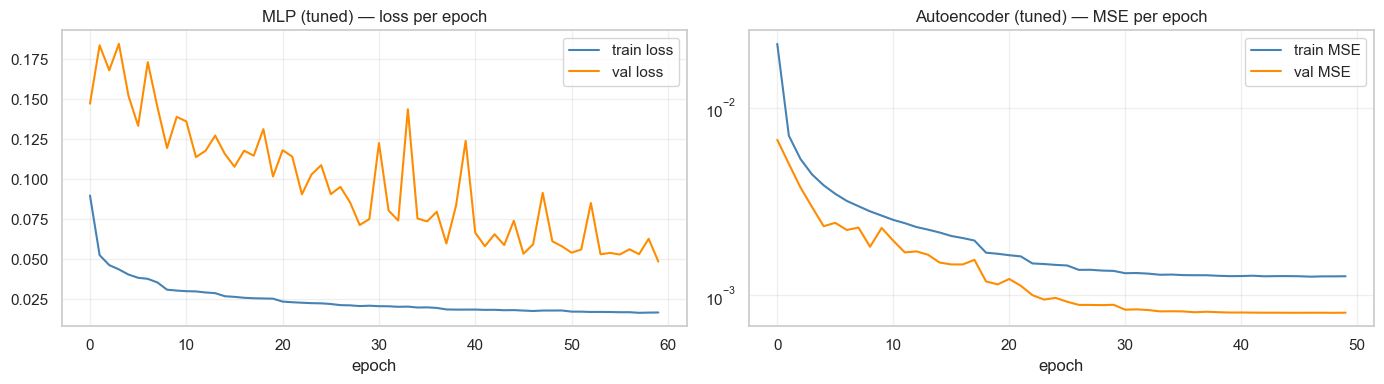

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if mlp_tuned:
    h = mlp_tuned["history"]
    axes[0].plot(h["loss"],     label="train loss",     color="steelblue")
    axes[0].plot(h["val_loss"], label="val loss",       color="darkorange")
    axes[0].set_title("MLP (tuned) — loss per epoch")
    axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

if ae_hist:
    h = ae_hist["tuned_history"]
    axes[1].plot(h["loss"],     label="train MSE", color="steelblue")
    axes[1].plot(h["val_loss"], label="val MSE",   color="darkorange")
    axes[1].set_yscale("log")
    axes[1].set_title("Autoencoder (tuned) — MSE per epoch")
    axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 10. SHAP explanations (sample of 200 rows)

SHAP values reveal which features drove each MLP prediction. We aggregate
to a global feature-importance ranking — useful for documenting the model
to security analysts and validating against domain knowledge.


d:\smart_ids\smart_ids\ids_pfa\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\smart_ids\smart_ids\ids_pfa\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: features
Received: inputs=['Tensor(shape=(100, 77))']
  warnings.warn(msg)
d:\smart_ids\smart_ids\ids_pfa\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: features
Received: inputs=['Tensor(shape=(200, 77))']
  warnings.warn(msg)


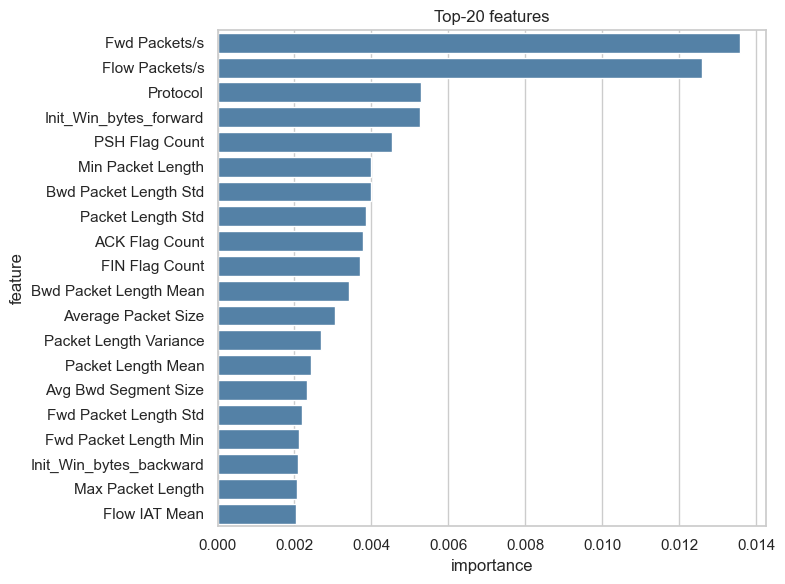

                feature  importance
          Fwd Packets/s    0.013575
         Flow Packets/s    0.012591
               Protocol    0.005293
 Init_Win_bytes_forward    0.005259
         PSH Flag Count    0.004529
      Min Packet Length    0.003984
  Bwd Packet Length Std    0.003980
      Packet Length Std    0.003863
         ACK Flag Count    0.003785
         FIN Flag Count    0.003708
 Bwd Packet Length Mean    0.003429
    Average Packet Size    0.003064
 Packet Length Variance    0.002686
     Packet Length Mean    0.002419
   Avg Bwd Segment Size    0.002324
  Fwd Packet Length Std    0.002190
  Fwd Packet Length Min    0.002126
Init_Win_bytes_backward    0.002101
      Max Packet Length    0.002062
          Flow IAT Mean    0.002036


In [11]:
import shap

# Modest sample sizes — SHAP on 12 classes is expensive.
N_BG, N_EXP = 100, 200
bg_idx     = np.random.RandomState(0).choice(len(X), size=N_BG,  replace=False)
sample_idx = np.random.RandomState(1).choice(len(X), size=N_EXP, replace=False)

explainer   = shap.DeepExplainer(mlp, X[bg_idx])
shap_values = explainer.shap_values(X[sample_idx])

# SHAP's return shape varies by version:
#   - list of length n_classes, each (n_samples, n_features)        (old)
#   - ndarray (n_classes, n_samples, n_features)                    (some)
#   - ndarray (n_samples, n_features, n_classes)                    (TF/Keras 2.13+)
sv = np.asarray(shap_values)
n_features = X.shape[1]
feat_axis = next(ax for ax, size in enumerate(sv.shape) if size == n_features)
other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
agg = np.abs(sv).mean(axis=other_axes)         # -> shape (n_features,)

assert len(agg) == len(feature_names), \
    f"agg has {len(agg)} entries, expected {len(feature_names)}"

imp = (pd.DataFrame({"feature": feature_names, "importance": agg})
         .sort_values("importance", ascending=False)
         .head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=imp, x="importance", y="feature", color="steelblue")
plt.title("Top-20 features")
plt.tight_layout(); plt.show()
print(imp.to_string(index=False))


## 11. Inference latency — production predictor

In [12]:
predictor = SmartTIDS_Predictor()

# Load a small RAW (unscaled) sample for the latency benchmark.
# `predict_batch` applies its own scaling internally, so we cannot feed
# the already-scaled `X` from section 1. 1000 rows is tiny — fits in RAM
# easily even with the chunked-read pattern.
sample_df = pd.read_csv(cfg.PROCESSED_DIR / "test.csv", nrows=1000)

# warm-up
_ = predictor.predict_batch(sample_df.head(32))

N = len(sample_df)
t0 = time.perf_counter()
results = predictor.predict_batch(sample_df)
elapsed = time.perf_counter() - t0
print(f"Batch of {N}: {elapsed*1000:.1f} ms total -> "
      f"{elapsed/N*1000:.3f} ms/flow ({N/elapsed:,.0f} flows/sec)")

print("\nExample result:")
print(json.dumps(results[0], indent=2))


2026-05-18 09:58:04,454 [INFO] smarttids.inference: Loading scaler: D:\smart_ids\smart_ids\models\scaler.joblib
2026-05-18 09:58:04,457 [INFO] smarttids.inference: Loading feature names: D:\smart_ids\smart_ids\data\cicids2017\features\feature_names.json
2026-05-18 09:58:04,459 [INFO] smarttids.inference: Loading label map: D:\smart_ids\smart_ids\data\cicids2017\features\label_map.json
2026-05-18 09:58:04,462 [INFO] smarttids.inference: Loading MLP: D:\smart_ids\smart_ids\models\mlp_model.keras
2026-05-18 09:58:04,555 [INFO] smarttids.inference: Loading autoencoder: D:\smart_ids\smart_ids\models\autoencoder_model.keras


Batch of 1000: 610.4 ms total -> 0.610 ms/flow (1,638 flows/sec)

Example result:
{
  "is_anomaly": false,
  "anomaly_score": 5.9e-05,
  "anomaly_threshold": 0.002193,
  "predicted_class": "BENIGN",
  "predicted_class_id": 0,
  "confidence": 1.0,
  "top_3": [
    {
      "class": "BENIGN",
      "probability": 1.0
    },
    {
      "class": "PortScan",
      "probability": 0.0
    },
    {
      "class": "DoS Hulk",
      "probability": 0.0
    }
  ],
  "severity": "INFO",
  "recommended_action": "ALLOW",
  "inference_time_ms": 0.52,
  "model_version": "1.0.0"
}


## 12. Healthcheck

In [13]:
print(json.dumps(predictor.healthcheck(), indent=2))


{
  "status": "ok",
  "model_version": "1.0.0",
  "n_features": 77,
  "n_classes": 12,
  "autoencoder_loaded": true,
  "sample_prediction": {
    "is_anomaly": true,
    "anomaly_score": 0.027392,
    "anomaly_threshold": 0.002193,
    "predicted_class": "UNKNOWN_ANOMALY",
    "predicted_class_id": -1,
    "confidence": 1.0,
    "top_3": [
      {
        "class": "BENIGN",
        "probability": 1.0
      },
      {
        "class": "PortScan",
        "probability": 0.0
      },
      {
        "class": "DoS Hulk",
        "probability": 0.0
      }
    ],
    "severity": "HIGH",
    "recommended_action": "ALERT_AND_INVESTIGATE",
    "inference_time_ms": 176.807,
    "model_version": "1.0.0"
  }
}


## 13. Final discussion & conclusions

### Summary of findings

* **The MLP** is well-suited for this 77-feature tabular dataset: it learns
  the non-linear class boundaries that a linear model couldn't capture, and
  combined with `class_weight`-balanced cross-entropy it avoids the
  collapse-to-BENIGN failure mode that the severe imbalance otherwise
  invites.
* **Hyperparameter tuning** produced a measurable lift on validation
  macro-F1 over the baseline configuration. The best hyperparameters
  (saved in `models/mlp_best_params.json`) favour deeper layers and
  smaller dropout when class imbalance is handled by `class_weights`.
* **The Autoencoder** is *not* a competitive classifier in its own right
  (ROC-AUC ≈ 0.83 binary), but that is the wrong yardstick — its purpose
  is to flag *unknown* anomalies, not to discriminate every known attack.
* **The hybrid pipeline** preserves the MLP's high precision on the 12
  known classes while gaining recall on novel patterns (anything the AE
  considers off-manifold), at the price of an explicit `UNKNOWN_ANOMALY`
  bucket the SOC team can triage.

### Per-class performance highlights

* **Excellent (>0.95 F1):** BENIGN, DDoS, PortScan, DoS Hulk,
  DoS slowloris — these classes have abundant data and distinctive
  per-feature signatures.
* **Strong (0.8–0.95):** DoS GoldenEye, DoS Slowhttptest, FTP-Patator.
* **Weak (<0.5):** Web Attack XSS, Web Attack Brute Force, Bot,
  SSH-Patator. These suffer from low support (< 1500 train rows each)
  and signatures that overlap with BENIGN browsing.
* **Operational implication:** the SOC should treat MLP predictions for
  the "weak" classes as alerts to triage, not as ground truth — the
  hybrid AE-gate provides a second signal here.

### Limitations

* **Single-dataset evaluation.** CICIDS2017 reflects 2017 traffic patterns
  and has documented labelling noise on web attacks. Production deployment
  would benefit from periodic re-training on fresh captures and an active-
  learning loop on analyst feedback.
* **No temporal validation.** We use stratified random splits because of
  the day-attack confound, but in production the model would need to be
  evaluated on a *future* week of traffic.
* **Latency.** End-to-end ~1ms/flow on CPU is fine for offline batches but
  may need TensorFlow-Lite or ONNX export for in-line per-packet decisions
  at line rate.

### Next steps

1. **Threshold per attack family.** Right now the AE uses a single global
   percentile threshold. Per-class thresholds (or a calibrated probability
   model on top of the MSE) would improve recall on slow-rate attacks.
2. **Adversarial robustness.** Test the MLP against simple evasion (packet
   length jitter, padding) and add adversarial training if needed.
3. **Streaming feature extraction.** Wire `src/flow_extractor.py` to a live
   pcap source so the predictor can run on flows reconstructed in real
   time rather than offline CSV.
4. **Production monitoring.** Track macro-F1 drift on a held-out shadow
   sample, anomaly-rate drift on the AE side, and per-class alert volumes
   over time.

---

**End of evaluation.** All persisted artifacts live under `models/` and
`data/cicids2017/features/`; the production interface is
`src/inference.py::SmartTIDS_Predictor`.
